# Fine-Grained Traffic Sign Classifier Setup (Cosine Similarity + DINOv2)

This notebook builds a fine-grained classifier that works after YOLO coarse detection:

1. Crop each traffic-sign object from MTSD annotations.
2. Embed each crop with DINOv2.
3. Group embeddings by fine-grained class.
4. Compute one mean vector per fine class.
5. Report per-class cosine-distance statistics (mean, variance, std, min, max).
6. Save reusable artifacts:
   - `fine_class_means.npz`: tensor of shape `(n_class, n_embed)`
   - `fine_class_to_index.json`: map `{class_name: class_index}`
   - `coarse_to_fine_indices.json`: map `{coarse_label: [class_index, ...]}`

Use these artifacts later to classify a YOLO-detected coarse label into its fine class by nearest cosine similarity within that coarse group.

In [1]:
import json
import re
from collections import defaultdict
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

try:
    from transformers import AutoImageProcessor, AutoModel
except ImportError as exc:
    raise ImportError(
        "Please install transformers first (pip install transformers)."
    ) from exc


PROJECT_ROOT = Path('/home/minh-le-vo-nhat/Documents/Minh-DUT/Ky-8-2025-2026/BigData/BTNhom')
DATA_ROOT = PROJECT_ROOT / 'Data'
CODE_ROOT = PROJECT_ROOT / 'code'

ANNOTATION_ROOT = DATA_ROOT / 'mtsd_fully_annotated_annotation' / 'mtsd_v2_fully_annotated'
ANNOTATIONS_DIR = ANNOTATION_ROOT / 'annotations'

IMAGES_SPLIT_DIRS = {
    'train': DATA_ROOT / 'mtsd_fully_annotated_images.train.full' / 'images',
    'val': DATA_ROOT / 'mtsd_fully_annotated_images.val' / 'images',
    'test': DATA_ROOT / 'mtsd_fully_annotated_images.test' / 'images',
}

ARTIFACT_DIR = CODE_ROOT / 'cosine_fine_classifier'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

MEAN_NPZ_PATH = ARTIFACT_DIR / 'fine_class_means.npz'
FINE2IDX_JSON_PATH = ARTIFACT_DIR / 'fine_class_to_index.json'
COARSE2IDXS_JSON_PATH = ARTIFACT_DIR / 'coarse_to_fine_indices.json'
INDEX2FINE_JSON_PATH = ARTIFACT_DIR / 'index_to_fine_class.json'
STATS_CSV_PATH = ARTIFACT_DIR / 'fine_class_cosine_stats.csv'
META_JSON_PATH = ARTIFACT_DIR / 'embed_metadata.json'

MODEL_ID = 'facebook/dinov2-base'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# Optional cap for quick experiments. Set None to use all samples.
MAX_SAMPLES_PER_FINE = None

HIGH_LEVEL_RE = re.compile(r'^([A-Za-z]+)--([A-Za-z0-9-]+)--g\\d+$')

/home/minh-le-vo-nhat/anaconda3/envs/ts-env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def normalize_label(raw_label: str) -> str:
    if raw_label == 'other-sign':
        return raw_label
    match = HIGH_LEVEL_RE.match(raw_label)
    if match:
        return match.group(1)
    return raw_label.split('--', 1)[0]


def iter_bbox_parts(bbox: dict) -> list[dict]:
    if 'cross_boundary' in bbox:
        cb = bbox['cross_boundary']
        return [cb['left'], cb['right']]
    return [bbox]


def find_image_path(image_key: str) -> Path:
    for split_dir in IMAGES_SPLIT_DIRS.values():
        candidate = split_dir / f'{image_key}.jpg'
        if candidate.exists():
            return candidate
    for split_dir in IMAGES_SPLIT_DIRS.values():
        matches = list(split_dir.glob(f'{image_key}.*'))
        if matches:
            return matches[0]
    raise FileNotFoundError(f'Cannot find image for key: {image_key}')


def crop_from_bbox(image_bgr: np.ndarray, bbox: dict) -> np.ndarray | None:
    h, w = image_bgr.shape[:2]
    xmin = max(0, min(int(np.floor(float(bbox['xmin']))), w - 1))
    xmax = max(0, min(int(np.ceil(float(bbox['xmax']))), w))
    ymin = max(0, min(int(np.floor(float(bbox['ymin']))), h - 1))
    ymax = max(0, min(int(np.ceil(float(bbox['ymax']))), h))
    if xmax <= xmin or ymax <= ymin:
        return None
    crop = image_bgr[ymin:ymax, xmin:xmax]
    if crop.size == 0:
        return None
    return crop


def l2_normalize(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    return x / np.clip(np.linalg.norm(x, axis=-1, keepdims=True), eps, None)


def load_dinov2(model_id: str = MODEL_ID, device: str = DEVICE):
    processor = AutoImageProcessor.from_pretrained(model_id)
    model = AutoModel.from_pretrained(model_id).to(device)
    model.eval()
    return processor, model


def embed_crop_dinov2(crop_bgr: np.ndarray, processor, model, device: str = DEVICE) -> np.ndarray:
    crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
    inputs = processor(images=crop_rgb, return_tensors='pt', input_data_format='channels_last')
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(**inputs)
        if hasattr(outputs, 'pooler_output') and outputs.pooler_output is not None:
            embedding = outputs.pooler_output
        else:
            embedding = outputs.last_hidden_state[:, 0, :]
        embedding = F.normalize(embedding, dim=1)
    return embedding.squeeze(0).detach().cpu().numpy().astype(np.float32)


print(f'Device: {DEVICE}')

Device: cuda


In [5]:
processor, dinov2_model = load_dinov2()

# annotation_files = sorted(ANNOTATIONS_DIR.glob('*.json'))
# if not annotation_files:
#     raise FileNotFoundError(f'No annotation files found in {ANNOTATIONS_DIR}')

# embeds_by_fine: dict[str, list[np.ndarray]] = defaultdict(list)
# coarse_by_fine: dict[str, str] = {}
# skipped_boxes = 0

# for ann_path in tqdm(annotation_files, desc='Embedding annotated objects'):
#     ann_data = json.loads(ann_path.read_text())
#     image_key = ann_path.stem

#     try:
#         image_path = find_image_path(image_key)
#     except FileNotFoundError:
#         continue

#     image = cv2.imread(str(image_path))
#     if image is None:
#         continue

#     for obj in ann_data.get('objects', []):
#         fine_label = obj['label']
#         coarse_label = normalize_label(fine_label)

#         existing = coarse_by_fine.get(fine_label)
#         if existing is None:
#             coarse_by_fine[fine_label] = coarse_label
#         elif existing != coarse_label:
#             raise ValueError(f'Inconsistent coarse label for {fine_label}: {existing} vs {coarse_label}')

#         if MAX_SAMPLES_PER_FINE is not None and len(embeds_by_fine[fine_label]) >= MAX_SAMPLES_PER_FINE:
#             continue

#         for bbox_part in iter_bbox_parts(obj['bbox']):
#             crop = crop_from_bbox(image, bbox_part)
#             if crop is None:
#                 skipped_boxes += 1
#                 continue

#             emb = embed_crop_dinov2(crop, processor, dinov2_model)
#             embeds_by_fine[fine_label].append(emb)

#             if MAX_SAMPLES_PER_FINE is not None and len(embeds_by_fine[fine_label]) >= MAX_SAMPLES_PER_FINE:
#                 break

# fine_classes = sorted(embeds_by_fine.keys())
# if not fine_classes:
#     raise RuntimeError('No embeddings were collected. Check paths and annotation format.')

# print(f'Fine classes collected: {len(fine_classes)}')
# print(f'Skipped invalid boxes: {skipped_boxes}')
# print('Example classes:', fine_classes[:10])

Loading weights: 100%|██████████| 223/223 [00:00<00:00, 3369.68it/s]


In [ ]:
stats_rows = []
fine_to_index: dict[str, int] = {}
index_to_fine: dict[int, str] = {}
coarse_to_fine_indices: dict[str, list[int]] = defaultdict(list)

first_embed = embeds_by_fine[fine_classes[0]][0]
embed_dim = int(first_embed.shape[0])
mean_vectors = np.zeros((len(fine_classes), embed_dim), dtype=np.float32)

for idx, fine_label in enumerate(tqdm(fine_classes, desc='Computing class means + cosine stats')):
    class_embeds = np.stack(embeds_by_fine[fine_label], axis=0).astype(np.float32)
    class_embeds_norm = l2_normalize(class_embeds)

    mean_vec = class_embeds_norm.mean(axis=0, keepdims=True)
    mean_vec = l2_normalize(mean_vec)[0]

    cosine_sim = class_embeds_norm @ mean_vec
    cosine_dist = 1.0 - cosine_sim

    mean_vectors[idx] = mean_vec
    fine_to_index[fine_label] = idx
    index_to_fine[idx] = fine_label

    coarse_label = coarse_by_fine[fine_label]
    coarse_to_fine_indices[coarse_label].append(idx)

    stats_rows.append(
        {
            'fine_label': fine_label,
            'coarse_label': coarse_label,
            'n_samples': int(class_embeds.shape[0]),
            'mean_cosine_distance': float(np.mean(cosine_dist)),
            'var_cosine_distance': float(np.var(cosine_dist)),
            'std_cosine_distance': float(np.std(cosine_dist)),
            'min_cosine_distance': float(np.min(cosine_dist)),
            'max_cosine_distance': float(np.max(cosine_dist)),
        }
    )

stats_df = pd.DataFrame(stats_rows).sort_values(['coarse_label', 'fine_label']).reset_index(drop=True)

np.savez_compressed(MEAN_NPZ_PATH, mean_vectors=mean_vectors)
FINE2IDX_JSON_PATH.write_text(json.dumps(fine_to_index, indent=2, ensure_ascii=False))
INDEX2FINE_JSON_PATH.write_text(json.dumps({str(k): v for k, v in index_to_fine.items()}, indent=2, ensure_ascii=False))
COARSE2IDXS_JSON_PATH.write_text(json.dumps(coarse_to_fine_indices, indent=2, ensure_ascii=False))
stats_df.to_csv(STATS_CSV_PATH, index=False)

META_JSON_PATH.write_text(
    json.dumps(
        {
            'model_id': MODEL_ID,
            'device': DEVICE,
            'embedding_dim': embed_dim,
            'n_fine_classes': len(fine_classes),
            'normalized_mean_vectors': True,
            'mean_vector_shape': list(mean_vectors.shape),
        },
        indent=2,
        ensure_ascii=False,
    )
)

print('Saved artifacts:')
print('-', MEAN_NPZ_PATH)
print('-', FINE2IDX_JSON_PATH)
print('-', INDEX2FINE_JSON_PATH)
print('-', COARSE2IDXS_JSON_PATH)
print('-', STATS_CSV_PATH)
print('-', META_JSON_PATH)
print()

display(stats_df.head(20))
print('Overall class count:', len(fine_classes))
print('Mean vector matrix shape:', mean_vectors.shape)

## Optional: Fine classification after YOLO coarse detection

Use this section later during inference:

1. YOLO predicts a coarse class for each detection box.
2. Crop the detected region.
3. Embed crop with DINOv2.
4. Compare only against fine-class means that belong to that coarse label.
5. Pick the nearest class by cosine similarity.

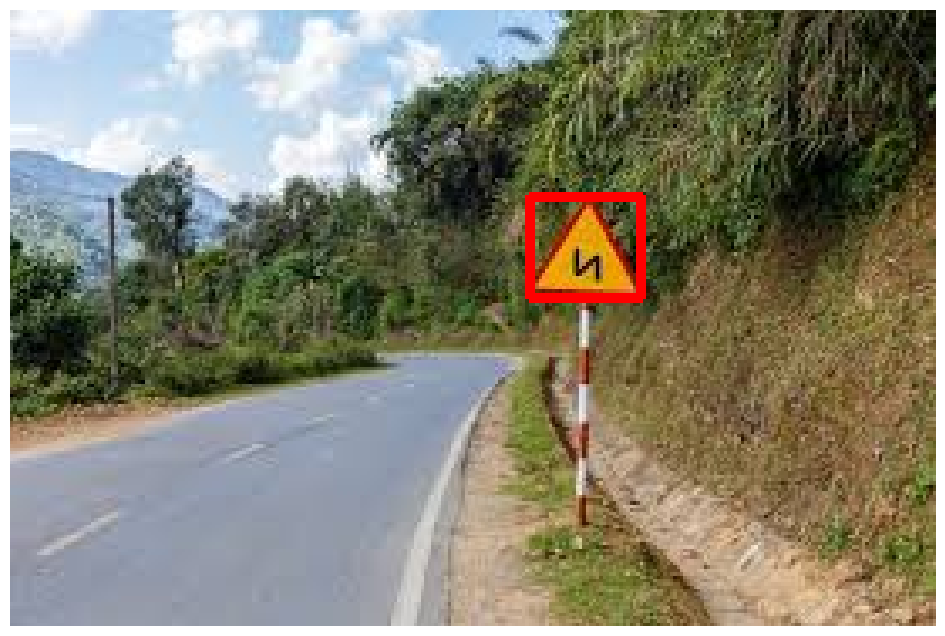

,coarse_label,fine_label,cosine_similarity,conf_yolo,x1,y1,x2,y2
0,warning,warning--double-curve-first-right--g1,0.826721,0.699265,154,55,187,85


In [17]:
from ultralytics import YOLO
from PIL import Image

def classify_fine_from_coarse(
    crop_bgr: np.ndarray,
    coarse_label: str,
    processor,
    model,
    mean_vectors: np.ndarray,
    index_to_fine_map: dict[int, str],
    coarse_to_indices_map: dict[str, list[int]],
) -> tuple[str | None, float | None]:
    candidate_indices = coarse_to_indices_map.get(coarse_label, [])
    if not candidate_indices:
        return None, None

    emb = embed_crop_dinov2(crop_bgr, processor, model)
    emb = emb / np.clip(np.linalg.norm(emb), 1e-12, None)

    candidate_matrix = mean_vectors[candidate_indices]
    sims = candidate_matrix @ emb
    best_local_idx = int(np.argmax(sims))
    best_global_idx = int(candidate_indices[best_local_idx])
    return index_to_fine_map[best_global_idx], float(sims[best_local_idx])


def predict_image_fine_labels(
    image_path: str | Path,
    label_path: str | Path,
    yolo_model_path: str | Path,
    yolo_coarse_names: list[str],
    conf: float = 0.25,
) -> pd.DataFrame:
    image_path = Path(image_path)
    label_path = Path(label_path)
    yolo_model = YOLO(str(yolo_model_path))

    result = yolo_model.predict(source=str(image_path), conf=conf, verbose=False)[0]
    image_bgr = cv2.imread(str(image_path))
    if image_bgr is None:
        raise FileNotFoundError(f'Could not read image: {image_path}')
    # ------------------
    image_display = image_bgr.copy()
    if label_path.exists() and label_path.read_text().strip():
        for line in label_path.read_text().splitlines():
            class_id, x_center, y_center, box_width, box_height = map(float, line.split())
            class_id = int(class_id)
            h, w = image_display.shape[:2]
            xmin = int((x_center - box_width / 2) * w)
            ymin = int((y_center - box_height / 2) * h)
            xmax = int((x_center + box_width / 2) * w)
            ymax = int((y_center + box_height / 2) * h)
            cv2.rectangle(image_display, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)
            cv2.putText(
                image_display,
                str(class_id),
                (xmin, max(0, ymin - 6)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 0),
                2,
                cv2.LINE_AA,
            )
    # ------------------
    means = np.load(MEAN_NPZ_PATH)['mean_vectors'].astype(np.float32)
    with open(INDEX2FINE_JSON_PATH, 'r', encoding='utf-8') as f:
        idx2fine_json = json.load(f)
    with open(COARSE2IDXS_JSON_PATH, 'r', encoding='utf-8') as f:
        coarse2idxs_json = json.load(f)

    index_to_fine_map = {int(k): v for k, v in idx2fine_json.items()}
    coarse_to_indices_map = {k: [int(x) for x in v] for k, v in coarse2idxs_json.items()}

    rows = []
    for box in result.boxes:
        coarse_idx = int(box.cls.item())
        coarse_label = yolo_coarse_names[coarse_idx]

        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = max(0, x2), max(0, y2)
        cv2.rectangle(image_display, (x1, y1), (x2, y2), (0, 0, 255), 2)
        if x2 <= x1 or y2 <= y1:
            continue

        crop = image_bgr[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        fine_label, cosine_sim = classify_fine_from_coarse(
            crop_bgr=crop,
            coarse_label=coarse_label,
            processor=processor,
            model=dinov2_model,
            mean_vectors=means,
            index_to_fine_map=index_to_fine_map,
            coarse_to_indices_map=coarse_to_indices_map,
        )

        rows.append(
            {
                'coarse_label': coarse_label,
                'fine_label': fine_label,
                'cosine_similarity': cosine_sim,
                'conf_yolo': float(box.conf.item()),
                'x1': int(x1),
                'y1': int(y1),
                'x2': int(x2),
                'y2': int(y2),
            }
        )

    return pd.DataFrame(rows), image_display


# Example usage (adjust paths + coarse class list from your YOLO data config):
yolo_best = CODE_ROOT / 'runs' / 'traffic_sign_yolov8_highlevel' / 'weights' / 'best.pt'
coarse_names = ['other-sign', 'complementary', 'information', 'regulatory', 'warning']
# img_path = IMAGES_SPLIT_DIRS['val'] / '-qrm38JkBGU3JvOoYQmqig.jpg'
# label_path = Path('/home/minh-le-vo-nhat/Documents/Minh-DUT/Ky-8-2025-2026/BigData/BTNhom/code/yolo_mtsd_highlevel/labels/val') / '-qrm38JkBGU3JvOoYQmqig.txt'
img_path = Path('/home/minh-le-vo-nhat/Documents/Minh-DUT/Ky-8-2025-2026/BigData/BTNhom/image.png')
label_path = './t'
df_pred, image_display = predict_image_fine_labels(
    image_path=img_path,
    label_path = label_path,
    yolo_model_path=yolo_best,
    yolo_coarse_names=coarse_names,
)
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(image_display, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()
display(df_pred)